# Key Methods in Physical Geography
# Computing Practical 2: Introduction to Programming in Python

This is a Jupyter notebook running on the University of Edinburgh Noteable Service (https://www.ed.ac.uk/information-services/learning-technology/noteable/about). Notebooks are interactive documents that can contain computer code (Python for this course), text and images.

For some components in this notebook, data files will be used. Any data file that is used for plotting with this and other notebooks needs to be uploaded to the Jupyter server -- though for today, these files are provided for you.

### Key Learning Outcomes

- Understand Modules: what they are, and why they are important in Python

- Understand Lists, Arrays, and their Distinctions 

- Plotting with Matplotlib

- Reading and plotting physical geography data in Python

- Formatting plots and figures

- Scatter plots

- Batch processing (`for`-loops) to serialise tasks


**IMPORTANT**: Be sure to run the cell immediately below, which contains the text
```python
!python produce_annual_rainfall_files.py
```
This will create data files that will be used later for plotting (so that you did not need to import 28 extra files). In fact, this command will itself call a file which packages Python code to be called outwith a notebook -- as notebooks are not the only way in which Python code can be run.

In [40]:
!python produce_annual_rainfall_files.py

Now that you have run this cell, you should see a number of files (e.g. `WoL_2001_rain.csv`) appear in your Jupyter folder for this practical. If you do not, please contact a demonstrator; these files will be required for plotting exercises later on!

## Comments

You saw examples of this in the previous notebook, but we will now touch on it explicitly. In addition to code for Python to execute, programs should always contain text comments to make them easier for human readers to understand. Comments can be used to explain what the code does to someone else reading your code or to remind you. Python ignores any lines of text (called a
docstring) between pairs of """ marks and anything on a line after a #, as in the cell below. If you run the cell, you will see the result is no different than it was before.

In [3]:
"""
Give an explanation of what the program does,
taking as many lines as you need
The purpoe of this space that contains text is for us readers to understand what the lines of python code actually mean
in human language. We can use it to further explain what the code means, entails, what previous code and what upcoming code 
might we expect. We do this by starting with apair of 3 quotaion marks next to each other.

"""
# This comment is ignored by Python and is used to remind me what I did in this line of code

print('Hello World!') # ... and so is this one 

Hello World!


## Key Learning: Modules

Python has some built-in functions, such as `len()` and the basic maths functions that we use for arithmetic, but collections of other functions can be imported from modules. Many modules have been developed for Python. Two of the most common are `NumPy` which has a host of general data analysis tools and `Matplotlib` which has key plotting features; but there are other more specialised modules for geo-data analysis, such as `Xarray` and `Rasterio`, which we will use later in the course.

**in the following you will be asked to type a number of sets of commands into the cell below, all of which do the same thing. It is suggested you delete commands before trying a new set. It might not be immediately clear what you are doing just yet, but with practice hopefully it will become so.**

Modules must be imported before you can use their functions, so it is convenient to import the
modules you need at the start of a program. There are several ways to import modules. For example,
NumPy contains a function called `arange()` which generates an array of equally spaced numbers in
a given range. If you supply an integer as an argument, it will make an array of that many numbers,
starting from zero, i.e. `arange(11)` returns the 11 numbers from 0 to 10. To do this in a program,
you could type

```python
import numpy
x = numpy.arange(11)
```

**Note that when you run these commands, nothing will happen!** You will need to then `print(x)` to see any output. *try it!*

We might want to type less when we use NumPy so we can set an abbreviation:

```python
import numpy as np
x = np.arange(11)
```

If you only want to use one function from a module you could import that, and then you need not type `np` afterwards:

```python
from numpy import arange
x = arange(11)
```

Or you could import everything from NumPy (but for certain modules this is not always advisable)

```python
from numpy import *
x = arange(11)
```

In the cell below use the 2nd option above to import numpy, and on the next line type 

```python
help(np.arange)
```
and run the cell. This will give more documentation for `arange`.

In [4]:
import numpy as np
x = np.arange(11)
print(x)
help(np.arange)

[ 0  1  2  3  4  5  6  7  8  9 10]
Help on built-in function arange in module numpy:

arange(...)
    arange([start,] stop[, step,], dtype=None, *, like=None)
    
    Return evenly spaced values within a given interval.
    
    ``arange`` can be called with a varying number of positional arguments:
    
    * ``arange(stop)``: Values are generated within the half-open interval
      ``[0, stop)`` (in other words, the interval including `start` but
      excluding `stop`).
    * ``arange(start, stop)``: Values are generated within the half-open
      interval ``[start, stop)``.
    * ``arange(start, stop, step)`` Values are generated within the half-open
      interval ``[start, stop)``, with spacing between values given by
      ``step``.
    
    For integer arguments the function is roughly equivalent to the Python
    built-in :py:class:`range`, but returns an ndarray rather than a ``range``
    instance.
    
    When using a non-integer step, such as 0.1, it is often better to u

If you printed out the documentation for `arange`, near the top you will see the way in which it should be called:

```python
arange([start,] stop[, step,], dtype=None)
```

This tells us that `arange` has several **arguments** (i.e. inputs), but the ones in square brackets are optional, and only the `stop` argument is necessary. So `arange(11)` will return (0,1, .. 10), but `arange(5,11)` will return (5,6, .. 10), as we have changed the `start` from a default of 1. Additionally we can specify the `step` argument to give *increments* other than 1.

In the following cell, write a program that prints numbers 0 to 10, one that prints numbers 1 to 10, and one that prints 0 to 1 in increments of 0.1. 

In [5]:
print(np.arange(0,11,1))
print(np.arange(1,11,1))
print(np.arange(0,1.1,0.1))

[ 0  1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## Key Learning: Lists versus Numpy Arrays

Python has a built-in function range() which returns a list of sequential integers – though you must tell python to use a list. Both of the following return the numbers 0 to 10: 
```python
var1 = list (range(11))
var2 = arange(11)
```
But `var1` and `var2` are fundamentally different types of objects. The first is a list; the second is an array. A Python list can contain any mix of data types but **you have to know what type of data you are dealing with to know which mathematical methods can be applied**. A NumPy array is similar to a list but can only contain integer or real numbers and therefore can be manipulated mathematically.

In the following cell an array and a list are declared, then each is added to itself. 

Modify it to add the value 3 to the array **only** and print the result; to multiply the array **only** by 3 (and print the result), and to multiply the array by itself (and print the result). Can you work out from the output what is being done in each case?

Now modify the code to do the same operations with the list. Are these operations allowed, i.e. is a result printed or is there an error? This is an example of an operation only being viable depending on the types of variables it is applied to. 

Note that `import numpy as np` is not called in this cell; this is because it was called in a previous cell. If the notebook were to restart (e.g. "Kernel" ==> "Restart") you would need to call it again in this cell. There is no harm, however, in doing so.

In [26]:
# Define an array and a list


x1 = np.arange(0,11)
x2 = list(range(0,11))

print(x1)
print(x2)

print('add the array to itself:')
print (x1 + x1)
print('add the list to itself:')
print (x2 + x2)

# operations on array

y1 = 3 + x1
print('adding 3 to the array of x1')
print(y1)

y2 = 3 * x1
print('multiplying 3 by the array of x1')
print(y2)

y3 = x1 * x1
print('multiplying the array of x1 by itself')
print(y3)

# operations on list

z1 = [3] + x2
print('adding single element list 3 to the list of x2')
print(z1)


z2 = 3 + x2
print('adding 3 to the list of x2: shows error')
print(z2)

z3 = 3 * x2
print('multiplying 3 by the list of x2: shows error')
print(z3)

z4 = x2 * x2
print('multiplying the list by itself')
print(z4)


[ 0  1  2  3  4  5  6  7  8  9 10]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
add the array to itself:
[ 0  2  4  6  8 10 12 14 16 18 20]
add the list to itself:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
adding 3 to the array of x1
[ 3  4  5  6  7  8  9 10 11 12 13]
multiplying 3 by the array of x1
[ 0  3  6  9 12 15 18 21 24 27 30]
multiplying the array of x1 by itself
[  0   1   4   9  16  25  36  49  64  81 100]
adding single element list 3 to the list of x2
[3, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


TypeError: unsupported operand type(s) for +: 'int' and 'list'

## Key Learning: Plotting in Python (Matplotlib)

You are now ready to create your first figure in Python. It will be a simple one!

The program below creates an array of `sin(x)` from 0 to 2$\pi$ and plots it, using small circles as markers (note that NumPy must be used for $\pi$ with `np.pi`). Run the cell to see what happens! Note there is a new module used: `matlplotlib.pyplot`, abbreviated as `plt`.

Now type 

``` python
help (plt.plot)
``` 

in the cell and run again to see the documentation for `plot`. There are some helpful examples near the top of the documentation. See if you can modify the code so that (a) there is a solid line, and (b) there is a red, solid line, and (c) there are blue '$+$' signs instead of blue dots. (once you are done with the documentation you can delete the `help (plt.plot)`.)

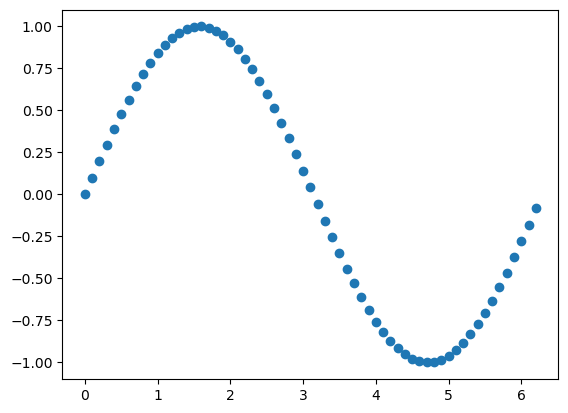

In [39]:
"""
Example plotting program
"""
# import the required modules
import matplotlib.pyplot as plt
import numpy as np
# create an array of numbers from 0 to 2 pi in increments of 0.1
x = np.arange(0, 2*np.pi, 0.1)
# create and array containing the sines of every number in x
y = np.sin(x)
# make and display a scatter plot of x and y

plt.plot(x, y, 'o')

plt.savefig('fig.png')

plt.savefig('fig.pdf')


### Figure file formats

You can save figures to files to use in papers and presentations. Figures are saved from the Matplotlib window in PNG (Portable Network Graphics) format by default, but several other image formats can be selected instead. In the previous cell, if you type

```python
plt.savefig('fig.png')
```

after the last figure is created, this figure will be saved automatically as `fig.png` in your working Jupyter notebook folder. (*check this!!!*) You can now download the file from the Jupyter file system.

You can tell Python what format you want to save an image in by selecting the extension on the end of the file name. For instance, 

```python
plt.savefig('fig.pdf')
```

will save the figure as Portable Document Format (.pdf).

## Key Learning: Reading and plotting physical geography data

**IMPORTANT!!!** If you have not run the very first cell of the notebook, which reads:
```python
!python produce_annual_rainfall_files.py
```
Do so now. Once you have done this, files `WoL_2***_rain.csv` and `WoL_2***_flow.csv` should appear in your Jupyter folder, where `2***` includes the years from 2001 to 2014. (check this!!!)

Data can be read from files, such as text or excel (.csv) files, and plotted using Python. The NumPy library can be used to read in data, but we will use a slightly different method -- it takes slightly longer, but introduces methods of handling data that are much more powerful and more widely used by geoscientific data scientists.

We are going make use of plots to compare rainfall and flow rate for the Water of Leith, here in Edinburgh. Data for rivers across the UK can be found at the National River Flow Archive (https://nrfa.ceh.ac.uk/data/search). The data we will use today has been downloaded for the gauging station for the Water of Leith at Murrayfield for 2014, the latest year for which there is complete data posted for both rainfall and flow -- but records go back to 1963 for this and many other rivers in the country.

There are two CSV-format files that have been copied over with your practical notebooks into your personal Jupyter space, WoL_2014_rain.csv and WoL_2014_flow.csv. A .csv file is a text file, but one that can be opened in Excel as a spreadsheet (you can download the files and try it). Each has two columns: a **Date** column and, for the flow rate file, a **Flowrate** column, in units of m$^3$/s; and for the rain file, a **Rainfall** column, in mm water per day within the catchment of the river at that point.

We are going to use the  **pandas** Python data analysis toolkit to extract the data from these files and plot it. Like NumPy, `pandas` is a module that we need to add, which then provides a number of useful function.

In the cell below, the `pandas` module is imported with alias `pd`. The function `read_csv` is then used to read the figure into a *variable* called `raindf`. This is a new concept -- `raindf` is not a number, or a character string, but an **object**. Specifically, it is a **data frame**, which is a *collection* of data that reflects what is in the .csv file, but in a useable form. In a sense, `raindf` a copy of the excel file which we can use in Python.

`pd.read_csv` can have a lot of extra *arguments* other than the name of the file, for instance if you only want to read a *portion* of the file, or you do not want to use every column (or if you do not like the column names!) You can pass *additional arguments* to `read_csv`, but these are optional -- you can see https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html for a description of these arguments. But in general, we use the simplest method of calling the function that will suit our purpose.

Immediately below this line, write an additional line to read the flow rate into a data frame called `flowdf`.

In [45]:
import pandas as pd

# import 2014 rainfall
raindf = pd.read_csv('WoL_2014_rain.csv')

# import 2014 flowrate
flowdf = pd.read_csv('WoL_2014_flow.csv')


If you type `raindf` in the next cell and run it, you will see an overview of the contents of the data frame. (Try it!) This will tell you how many rows there are in the file. It tells us the names of the data columns, which we can use to plot the data. (Note the last record is numbered **364** -- this is because the first record is numbered 0. Zero-indexing is very common in programming, and can cause difficulty if you are not aware of it!)

In [46]:
raindf

,Date,Rainfall
0,01/01/2014,4.7
1,02/01/2014,3.4
2,03/01/2014,5.9
3,04/01/2014,1.5
4,05/01/2014,3.7
...,...,...
360,27/12/2014,0.2
361,28/12/2014,0.1
362,29/12/2014,0.2
363,30/12/2014,0.0


To access the rainfall data, we use
```python
    rain = raindf.Rainfall
```
This provides an array (`rain`) which we can plot. 

In the cell below, use a similar method to assign `flowdf.Flowrate` to an array `flow` and then plot flow rate using Matplotlib.pyplot as before. Note that previously, we had arrays `x` and `y` to plot. Now we do not have a numerical variable for the $x$-axis (the "Date" column contains *strings* -- which we cannot plot). This is ok -- we can simply call `plt.plot(flow)`, which is equivalent to `plt.plot(np.arange(0,365),flow)`. What does the plot look like? How large does the flow rate get in 2014, and how often did this occur? What would have driven these high flow rates?

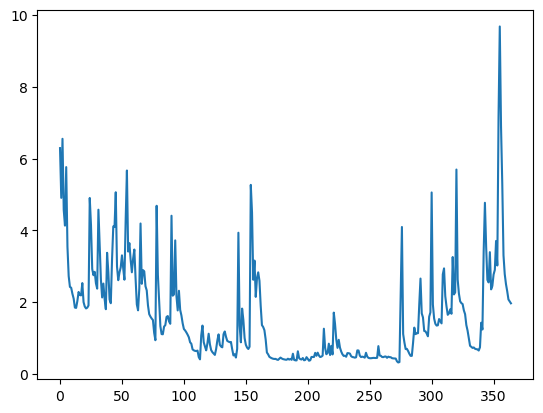

In [47]:
flow = flowdf.Flowrate

plt.plot(flow)

### Extra learning: Selecting and saving data with pandas

The annual 2014 files you are working with were themselves generated using `pandas`. You were provided "master" files `19006_cdr.csv` and `19006_gdf.csv` containing daily rain and flow data from 2001 to 2014. `pandas` provides a way to select *subsets* of data frames based on *criteria*, such as the year in which the data is gathered; these refined data frames can then be *saved* to excel .csv files for later reading (in Python or other applications). The commands to do this have been run already, but if you would like to see an explanation, you can look over the notebook `produce_annual_rainfall_files.ipynb`, which contains the same commands.

## Key Learning: Formatting plots

To make a plot look professional, it is important to be able to format it. This means labelling the axes properly, and controlling the font of axis labels. Let's start by labelling the axes. The function `plt.xlabel()` can be used to label the x axis, and takes a string as an argument e.g. `plt.xlabel('cat')`. `plt.ylabel()` is similar.

In the above figure, label the x-axis "Day of year", and the y-axis "Flow Rate (m$^3$/s)". To have a superscript, you will need to use mathematical formatting: 
```python
'm$^3$'
```
formats as m$^3$. For subscript, we use `_` instead of `^`. 

You can use an *optional* argument `fontsize` to change the size of the axis labels. This can be done by calling e.g.
```python
plt.xlabel('something',fontsize=15)
```
Experiment with changing the size of the font labels.

To do these tasks in the cell below, you will unfortunately need to copy and paste your code from the cell above to plot the `rain` variable. Once a plot is created within a notebook cell, it cannot be changed in subsequent cells (but can be changed by modifying the cell in which it was created!)

Using [this reference](https://matplotlib.org/3.3.2/api/_as_gen/matplotlib.pyplot.plot.html), try to change the line color to green. You can also find additional options for `plt.xlabel` [here]
(https://matplotlib.org/3.3.2/api/text_api.html#matplotlib.text.Text).



Text(0, 0.5, 'Flow Rate (m$^3$/s)')

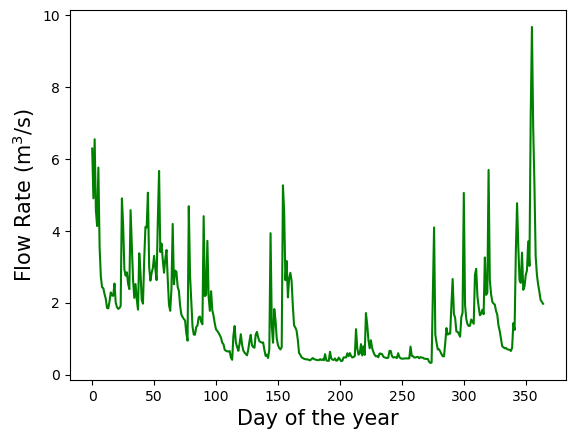

In [66]:
flow = flowdf.Flowrate
plt.plot(flow, 'g')

# formatting code below
plt.xlabel('Day of the year', fontsize=15)
plt.ylabel('Flow Rate (m$^3$/s)', fontsize=15)



Make a similar plot of rainfall, and make the curve red. What do you see? Can you make a comparison with flow rate?

Text(0, 0.5, 'Rainfall (mm/day)')

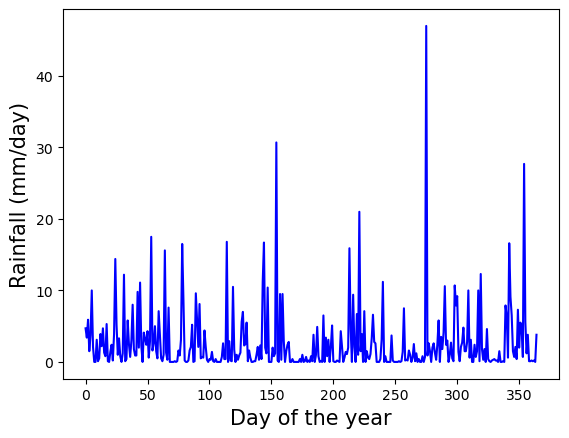

In [65]:
rain = raindf.Rainfall
plt.plot(rain,'b')

# formatting code below
plt.xlabel('Day of the year', fontsize=15)
plt.ylabel('Rainfall (mm/day)', fontsize=15)


## Key Learning: creating scatter plots

You have been looking at line plots of rainfall and flow rate -- how the values change over time. You may have tried to compare rainfall with flow rate by comparing the plots. There is a better way to do that in the form of *scatter plots*. Scatter plots do not show how a single variable evolves over time, but how two evolving variables correspond to each other. 

Python is quite flexible for plotting scatter plots. The basic syntax looks like:
```python
plt.scatter([x_values],[y_values])
```
where `[x_values]` and `[y_values]` will be replaced by the data sets you want to compare.

If you have gotten to this point, `rain` and `flow` should already be defined. In the following cell, create a scatter plot showing values of rain on the `x` axis and flow rate on the `y` axis. Label the axes appropriately.

Text(0, 0.5, 'flow (m$^3$/s)')

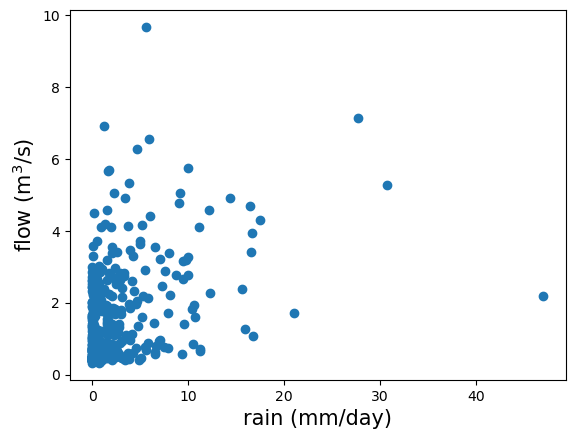

In [78]:
plt.scatter(rain,flow,marker='o')
plt.xlabel('rain (mm/day)', fontsize=15)
plt.ylabel('flow (m$^3$/s)', fontsize=15)

What do you see? What is more likely, a day with low rainfall and flow, or a day with high rainfall and flow? Does it seem like there is any relationship between the two? (We can quantify this -- but will do so only once we begin exploring statistics.) By default, matplotlib plots each data point as a blue filled circle. However this can be changed. The scatter plot reference can be found [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html). To change the marker for each point, the function call must be modified:
```python
plt.scatter([x_values],[y_values],marker=[markerstyle])
```
where `[markerstyle]` will be replaced by the appropriate style. Go back to your scatter plot and change the markers to plus signs with the markerstyle `'+'`. (Don't change the color -- we have something else planned here..)

One thing that is now missing (relative to the line plots) is that we don't know the time of year for a given data pair (x-y point) in the scatter plot. However, python provides an easy way to do this. In the above call to modify the marker, `marker` is a **kwarg** (keyword argument) -- we specify the argument explicitly by its name. There is another kwarg `c`, which can be used to set the *color* of the data points. `c` is set equal to a list of values. Let's say we want to set the color according to when the measurement occurred -- this list of values will be the day of the year. In the following cell, redo the scatter plot, but after the `marker` kwarg in the argument list, add another item specifying `c=np.arange(0,365)`. As we know, `np.arange(0,364)` is a list of days of the year. Your modification will color the markers according to day of year.

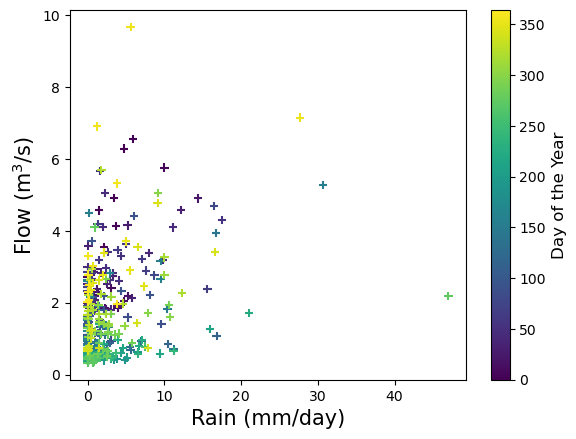

In [88]:
plt.scatter(rain,flow,marker='+',c=np.arange(0,365))
plt.xlabel('Rain (mm/day)', fontsize=15)
plt.ylabel('Flow (m$^3$/s)', fontsize=15)
cbar = plt.colorbar()
cbar.set_label('Day of the Year', fontsize=12)

If you have implemented this correctly, you will see a plot similar to the one you saw before, but each datapoint will have a different color. This coloring will respond to day-of-year -- but without a colorbar, you will not know which day corresponds to which color! 

Add to the code above, the line
```python
plt.colorbar()
```
and re-run the cell. You will see a colorbar with ticks to indicate the day of year corresponding to the color. Labeling the colorbar would be helpful, though. Instead of `plt.colorbar()` write `cbar=plt.colorbar()`: this will give us a *reference* variable to the colorbar with which we can make changes. The command `cbar.set_label()` will label the colorbar; this works exactly like `xlabel` and `ylabel`, in that you can pass as an argument a text string to describe the colorbar. Label the colorbar "day of year". Now you have a proper scatter plot! 

In the next practical, we will see how to use the statistical module to find correlation between Flow rate and Rainfall, quantifying the relationship between the plots.

We will encounter colorbars again when plotting raster data.

## Key Learning: using Batch Processing to plot from multiple data sources

A strength of using a programming language instead of a GIS tool is the potential to carry out **batch processing**. We will not carry out high-level batch-processing here but will introduce a **key component**: repetition of a set of simple commands, using a feature in Python called a **for-loop**. The for-loop allows us to write a set of commands that will be carried out multiple times, but with a simple, *predictable* change each time it is called. For instance, we may want to process a number of geotiff rasters containing canopy height, for the same location but in different years. If we can write code to process just one of these files, we can devise a for-loop to process as many files as we want -- *without taking the time to write the additional code*.

We will see this by using a very simple task which we would like to replicate -- plotting multiple sets of data in a single figure. In keeping with the river data theme, let's plot data from 5 separate years of WoL flow rate data -- but instead of 1 continuous series, overlaying the data on top of each other. However, we will only type a call the `plot` command once.

In the following cell, a for-loop is constructed, so named because it begins with the word `for`. A for-loop is basically telling Python, "for this collection of items... do these instructions".

The first line of the for-loop is:
```python
for year in np.arange(2001,2006):
```
We know that `np.arange` produces an array of values: `2001, 2002, 2003, 2004, 2005`. (why not 2006?) These are the years for which we want to plot flow data. *But how??*

The three following indented lines are then run *multiple* times -- once for each value in the array `np.arange(2001,2006)`. Importantly, each time the lines are called, the variable `year` has a different value. Thus we can write code which takes advantage of this changing variable, called a *loop variable*. Thus when `year=2003`, the for-loop will open, and plot, the file `WoL_2003_flow.csv`, and when `year=2005`, the for-loop will open, and plot, the file `WoL_2005_flow.csv`. This is done through the command
```python
df_year = pd.read_csv('WoL_' + str(year) + '_flow.csv')
```
This command converts the integer variable `year` to a string, and concatenates this string to produce the appropriate file name. With each new value of `year`, `df_year` then holds different data. We do not need to specify a line color, pyplot will do this for us. Note that we only write instructions to process the data once. **Imagine processing thousands of raster files, one at a time**.

In the following cell, try to construct a figure of flow rate for the years 2001 to 2014. After this, try modifying to produce a plot of annual *rainfall* for these years. To create a new figure within the same cell, type 

```python
plt.figure()
```

to indicate you are creating a new figure.

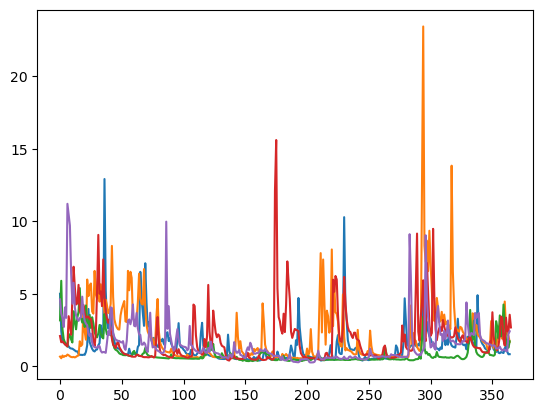

In [89]:
for year in np.arange(2001,2006):
    df_year = pd.read_csv('WoL_' + str(year) + '_flow.csv')
    flow = df_year.Flowrate
    plt.plot(flow)

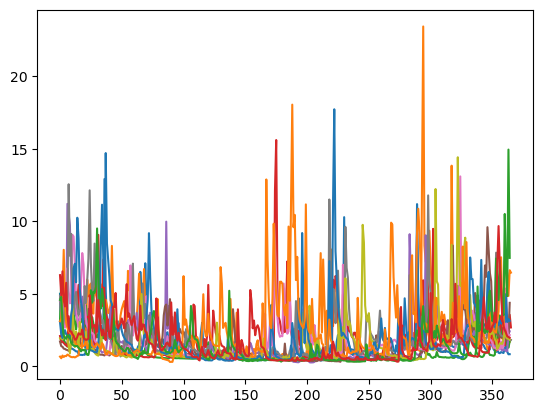

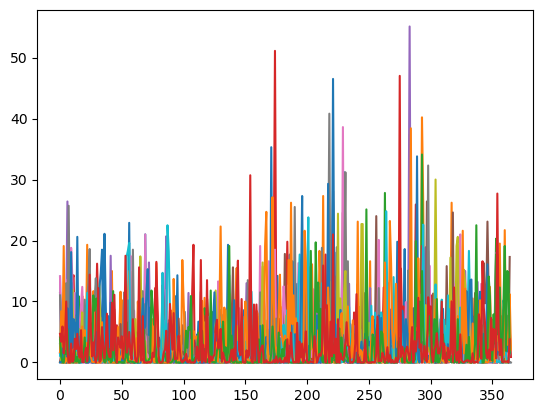

In [90]:
for year in np.arange(2001,2015):
    df_year = pd.read_csv('WoL_' + str(year) + '_flow.csv')
    flow = df_year.Flowrate
    plt.plot(flow)
    
plt.figure() 

for year in np.arange(2001,2015):
    df_year = pd.read_csv('WoL_' + str(year) + '_rain.csv')
    rain = df_year.Rainfall
    plt.plot(rain)

### Adding legends to figures

In the figures you created above, it is difficult to tell which line corresponds to which year. This is where figure **legends** are useful. To add a legend, we need to add a **label** to each line that we plot -- this is done using the `label` argument to `plot`. In the following cell, flow rate data from multiple years is plotted, and each time a plot is made, a label is assigned. Then the command `plt.legend()` is called, which creates a legend based on the label information given.

The label is always the same: "FlowLabel". Try to modify the code to indicate which curve corresponds to each year. *hint: use the* `year` *variable*.

In which year was the maximum flow rate measured?

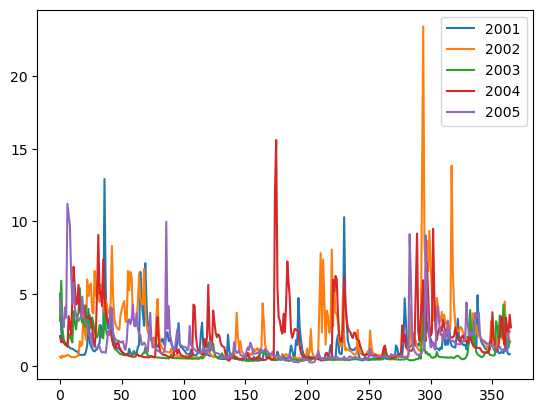

In [92]:
for year in np.arange(2001,2006):
    df_year = pd.read_csv('WoL_' + str(year) + '_flow.csv')
    flow = df_year.Flowrate
    plt.plot(flow,label=year)
plt.legend()      

## Further learning

The material below this point can be considered enrichment learning. If you do not go beyond this point, you have still met the learning objectives of this practical, but it is suggested you work through the exercises below at some point, 

### Modifying tick labels using lists

Having "Day of Year" as an x-label is not very convenient -- we have to guess where e.g. 1 May is on the plot. 

Let's relable the "ticks" on the plot according to the month. We can use matplotlib to pass in a list of labels, along with a list of "locations" for the labels. We use a function called `plt.xticks`:

```python
plt.xticks(locs,labels)
```
where the *arguments* `locs` and `labels` need to be lists giving the locations of the ticks and the labels you want to use. In this case, the "locations" are the first day of each month:
```python
listdays = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
```
For the list of month abbreviations, this is provided as a list called `month_abbr` in the `calendar` module. Import this using
```python
from calendar import month_abbr
```
With these two lists, use the `plt.xticks` function to label the bottom axis by month. However, the first entry in the list `month_abbr` is empty -- so we need to pass `month_abbr[1:]` as an argument. This might not make sense now, but you will see why in the next practical.

Note -- if you do not terminate the last line with a ";", you will see a lot of nonsense text before the plot!

Again, you will need to create the above figure anew in the next cell. 

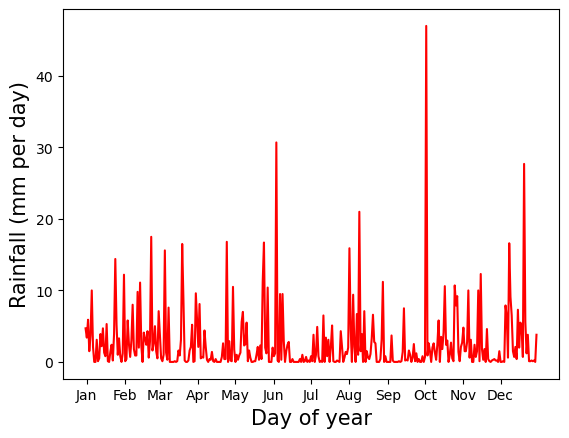

In [94]:
from calendar import month_abbr

listdays = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

rain = raindf.Rainfall
plt.plot(np.arange(0,365),rain,color='red')
plt.xlabel('Day of year',fontsize=15);
plt.ylabel('Rainfall (mm per day)',fontsize=15);

# use xticks to add ticks to plot 
plt.xticks(listdays,month_abbr[1:]);

### Plots with different scales

Sometimes we would like to plot related data in the same figure to allow better comparison, even if the two data sets are of differnt scales. It is possible to do this in Python with a few extra steps.

In the cell below, `plt.subplots` is called, even though it was not before. This gives us more control over the axes of the figure.

```python
_, ax1 = plt.subplots()
```
looks a bit strange. This way of calling a function means that two "objects" are returned. We do not care about the first, and so `_` is a placeholder. `ax1` is an object variable which lets us format the axes (and add an additional axis).

The commands to set the axis labels are slightly different than we used before. The comments below describe what each does. 

The command 
```python
ax2 = ax1.twinx()
```
creates a second axis to plot Flow Rate. Try to write similar commands, using `ax2` rather than `ax1`, to plot flow rate (in blue) on the right hand axis. 

You can additionally label the x tick labels by month, but things are slightly different. You must pass the locations with `ax1.set_ticks()` and the labels with `ax1.set_ticklabels()` separately. Try this as well.

If done correctly you will see rain and flow rate data on the same figure. This provides another way of comparing rainfall and flow in the same figure.

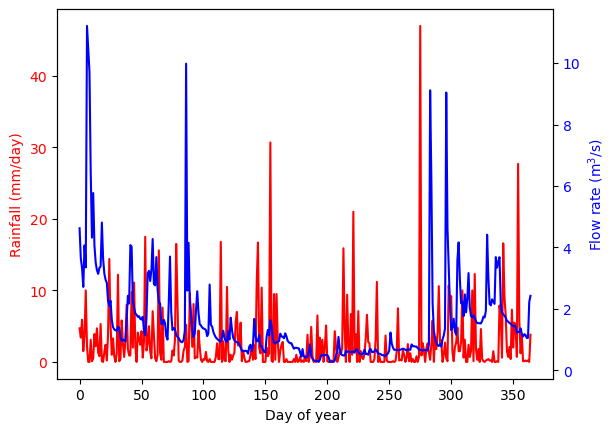

In [96]:
import matplotlib.pyplot as plt

_, ax1 = plt.subplots()

# set the x axis label
ax1.set_xlabel('Day of year')

# set the y axis label, and the text color
ax1.set_ylabel('Rainfall (mm/day)', color='red')

# plot rain data with a red curve
ax1.plot(rain, color='red')

# set the tick label color for rainfall to red
ax1.tick_params(axis='y', labelcolor='red')


# create a second axis to plot flow rate
ax2 = ax1.twinx()

ax2.set_ylabel('Flow rate (m$^3$/s)', color='blue')
ax2.plot(flow, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')